# **Notebook 2 — Pre-Analysis**

This notebook covers the pre-analysis stage of the Carrefour customer segmentation pipeline, working across **191 million purchase transactions** from 1.48 million customers over 6 months (Jan–Jun 2022). It validates data quality, builds the clean working dataset, and confirms through EDA that the customer population is behaviourally diverse enough to support meaningful segmentation.

**Outputs consumed by Notebook 3 (`03_ml_pipeline.ipynb`):**
- `data/processed/df_combined.parquet` — clean merged transaction dataset (Section 3)
- `data/processed/customer_kpis.parquet` — per-customer KPI table used in tribe profiling (Section 4.1)
- `data/processed/quality_report.json` — data quality audit record (Section 2)

## Pipeline Overview

| Section | Step | Output |
|---|---|---|
| 0 | Setup & imports | — |
| 1 | Data inventory | Schema + scale confirmation |
| 2 | Data quality gates (8 checks) | `quality_report.json` |
| 3 | Merge & clean | `df_combined.parquet` |
| 4 | Exploratory Data Analysis | `customer_kpis.parquet`, EDA charts, segmentation viability go/no-go |

## Section 0 — Setup & Imports

In [2]:
# Section 0 — Setup & Imports
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

from src.config import DATA_PROCESSED, OUTPUTS, SAMPLE_SIZE
from src.data_loader import load_maestra_articulos, load_linea_tickets

OUTPUTS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print("imports OK")

from src.config import MODE
print(MODE)

imports OK
prod


## Section 1 — Data Inventory

Before any modelling, we establish what we are actually working with. Two source files feed the pipeline:

- **`ie_maestra_articulos`** — the product master: ~894k SKU rows mapping each `idarticu` to a human-readable name and sector label. This is the reference table that will enrich every transaction with categorical context.
- **`ie_linea_ticket`** — the transactional backbone: every individual line item purchased across all stores and the full 6-month window. At 191M rows this is the primary modelling dataset.

The goal here is to confirm the data matches the project brief (1.48M customers, 191M rows, Jan–Jun 2022, 4 stores) and surface any immediate structural anomalies before we invest compute on quality checks and feature engineering.

In [9]:
# product master — ~893k product SKUs with sector labels
df_articles = load_maestra_articulos()

print(f"Shape: {df_articles.shape[0]:,} rows × {df_articles.shape[1]} cols")
print(f"Columns: {df_articles.columns}")

print("\nProducts per sector:")
print(
    df_articles.group_by(["idsector", "desc_sector"])
               .agg(pl.len().alias("n_products"))
               .sort("n_products", descending=True)
)
df_articles.head()

Shape: 893,944 rows × 4 cols
Columns: ['idarticu', 'desc_larga_articulo', 'idsector', 'desc_sector']

Products per sector:
shape: (6, 3)
┌──────────┬──────────────────────┬────────────┐
│ idsector ┆ desc_sector          ┆ n_products │
│ ---      ┆ ---                  ┆ ---        │
│ i64      ┆ str                  ┆ u32        │
╞══════════╪══════════════════════╪════════════╡
│ 3        ┆ BAZAR                ┆ 425050     │
│ 1        ┆ P.G.C.               ┆ 171672     │
│ 6        ┆ TEXTIL               ┆ 132735     │
│ 2        ┆ PROD. FRESCOS TRADIC ┆ 88033      │
│ 4        ┆ ELECTROFOTO          ┆ 75979      │
│ 7        ┆ GASOLINERA           ┆ 475        │
└──────────┴──────────────────────┴────────────┘


idarticu,desc_larga_articulo,idsector,desc_sector
i64,str,i64,str
966557,"""GUISO DE VERDURAS LITORAL 415 …",1,"""P.G.C."""
909163,"""LA HISTORIA DE LOS 3 CERDITOS …",3,"""BAZAR"""
594029,"""MUU (SUSAETA)""",3,"""BAZAR"""
86412,"""ALAS DE MOSCA PARA ÁNGEL ANAY…",3,"""BAZAR"""
507503,"""CAMISETA NINO MANGA LARGA SPID…",6,"""TEXTIL"""


In [10]:
# transaction lines — lazy frame over the full 191M-row dataset (never fully materialised)
df_tickets = load_linea_tickets()

# approx_n_unique uses HyperLogLog (~1% error, O(1) memory) for high-cardinality columns.
# Exact n_unique() on 18.5M ticket IDs or 1.46M customers builds a massive in-memory hash
# set across all streaming batches and is the primary cause of OOM crashes in prod mode.
scan = df_tickets.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").approx_n_unique().alias("n_customers"),
    pl.col("ticket").approx_n_unique().alias("n_tickets"),
    pl.col("idarticu").approx_n_unique().alias("n_products"),
    pl.col("fecha").min().alias("date_min"),
    pl.col("fecha").max().alias("date_max"),
    pl.col("idempres").n_unique().alias("n_stores"),   # 4 stores — exact is fine
]).collect(engine="streaming").row(0, named=True)

n_raw = scan["n_rows"]

print(f"Columns: {df_tickets.columns}")
print()
print(f"Total rows: {n_raw:>15,}")
print(f"Unique customers (approx): {scan['n_customers']:>15,}")
print(f"Unique tickets   (approx): {scan['n_tickets']:>15,}")
print(f"Unique products  (approx): {scan['n_products']:>15,}")
print(f"Date range: {scan['date_min']}  →  {scan['date_max']}")
print(f"Stores: {scan['n_stores']}")
print()

# monthly breakdown with inline bar
monthly_raw = (
    df_tickets.with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("month"))
              .group_by("month").agg(pl.len().alias("n"))
              .sort("month").collect(engine="streaming").to_pandas()
)
print("Monthly transaction volume:")
max_n = monthly_raw["n"].max()
for _, row in monthly_raw.iterrows():
    bar = "█" * int(row["n"] / max_n * 30)
    print(f"  {row['month']}  {row['n']:>12,}  {bar}")

Columns: ['idempres', 'fecha', 'hora', 'ticket', 'cliente', 'idarticu', 'unidades', 'importe', 'idpromoc', 'idtiprod']

Total rows:     191,017,715
Unique customers (approx):       1,475,682
Unique tickets   (approx):      20,204,403
Unique products  (approx):         100,798
Date range: 2022-01-01  →  2022-06-30
Stores: 4

Monthly transaction volume:
  2022-01    32,296,827  ████████████████████████████
  2022-02    29,521,934  █████████████████████████
  2022-03    34,077,920  ██████████████████████████████
  2022-04    30,614,164  ██████████████████████████
  2022-05    33,162,123  █████████████████████████████
  2022-06    31,344,747  ███████████████████████████


## Section 2 — Data Quality Gates

A segmentation pipeline built on dirty data will produce clusters that reflect data artefacts, not genuine customer behaviour. Before committing to any feature engineering, we run **eight automated checks** as hard gates:

| Check | What it validates |
|---|---|
| Schema validation | Both files have the expected columns and types |
| Null audit | No missing values in either dataset |
| Anomaly audit | Scale of negative/zero quantities and prices; determines the cleaning rule |
| Product coverage | ≥ 90% of ticket product IDs resolve in the master (orphaned products get no embedding) |
| Temporal completeness | All 6 calendar months present, each > 10M transactions |
| Customer activity | Distribution of tickets per customer; confirms enough active customers to cluster |
| Promotional integrity | `idpromoc` category counts and promo rate — a key behavioral axis in Phase 2 |
| Store integrity | Transaction volume and revenue per store |

All checks run regardless of failures so the full picture is visible at once. Results are saved to `data/processed/quality_report.json` for downstream reference.

In [11]:
from src.data_quality import (
    validate_schema, audit_nulls, audit_anomalies,
    check_product_coverage, check_temporal_completeness,
    audit_customer_activity, audit_promotional_data,
    audit_stores, build_quality_report,
)

# Loads quality_report.json from cache if it exists — no parquet scans needed.
# Pass force=True to re-run all 6 streaming scans (e.g. after raw data changes).
report = build_quality_report(verbose=True)

  DATA QUALITY REPORT — Carrefour Segmentation Pipeline

[null_audit + anomaly_audit]  (single combined scan)
  [null_audit]
  articles_nulls: {'idarticu': 0, 'desc_larga_articulo': 0, 'idsector': 0, 'desc_sector': 0}
  articles_total_nulls: 0
  ticket_null_counts: (10 entries)
  ticket_total_nulls: 0
  --> PASS
  [anomaly_audit]
  total_rows: 191017715
  anomaly_counts: {'negative_unidades': 0, 'zero_unidades': 0, 'extreme_unidades_gt1000': 3248, 'negative_importe': 287, 'zero_importe': 654909, 'extreme_importe_gt10k': 53}
  anomaly_pcts: {'negative_unidades': 0.0, 'zero_unidades': 0.0, 'extreme_unidades_gt1000': 0.0017, 'negative_importe': 0.0002, 'zero_importe': 0.3429, 'extreme_importe_gt10k': 0.0}
  rows_dropped_by_cleaning_rule: 655196
  rows_dropped_pct: 0.343
  rows_retained: 190362519
  rows_retained_pct: 99.657
  cleaning_rule: DROP unidades <= 0 OR importe <= 0
  --> PASS

[schema_validation]
  articles_columns: ['desc_larga_articulo', 'desc_sector', 'idarticu', 'idsector']


In [12]:
# ── Anomaly detail: understand scale of returns / bad data ──────────────────
anom = report["anomaly_audit"]
print(f"Total rows: {anom['total_rows']:>15,}")
print(f"Rows retained: {anom['rows_retained']:>15,}  ({anom['rows_retained_pct']:.2f}%)")
print(f"Rows dropped: {anom['rows_dropped_by_cleaning_rule']:>15,}  ({anom['rows_dropped_pct']:.2f}%)")
print()
print("Anomaly breakdown:")
for k, v in anom["anomaly_counts"].items():
    pct = anom["anomaly_pcts"][k]
    print(f"  {k:<35}: {v:>10,}  ({pct:.3f}%)")
print(f"\nCleaning rule: {anom['cleaning_rule']}")

Total rows:     191,017,715
Rows retained:     190,362,519  (99.66%)
Rows dropped:         655,196  (0.34%)

Anomaly breakdown:
  negative_unidades                  :          0  (0.000%)
  zero_unidades                      :          0  (0.000%)
  extreme_unidades_gt1000            :      3,248  (0.002%)
  negative_importe                   :        287  (0.000%)
  zero_importe                       :    654,909  (0.343%)
  extreme_importe_gt10k              :         53  (0.000%)

Cleaning rule: DROP unidades <= 0 OR importe <= 0


In [13]:
# ── Customer activity: confirm segmentation sample is viable ─────────────────
ca = report["customer_activity"]
print(f"Total unique customers  : {ca['total_unique_customers']:>10,}")
print(f"Eligible (>= {ca['min_tickets_threshold']} tickets)  : {ca['eligible_customers']:>10,}")
print(f"Ineligible              : {ca['ineligible_customers']:>10,}  ({ca['ineligible_pct']:.1f}%)")
print(f"Sample size feasible    : {ca['sample_size_feasible']}  (need 100,000)")
print()
print(f"Tickets per customer — distribution:")
print(f"  p10 = {ca['p10_tickets']:.0f}    p25 = {ca['p25_tickets']:.0f}    "
      f"median = {ca['median_tickets']:.0f}    mean = {ca['mean_tickets']:.1f}")
print(f"  p75 = {ca['p75_tickets']:.0f}    p95 = {ca['p95_tickets']:.0f}    "
      f"p99 = {ca['p99_tickets']:.0f}    max = {ca['max_tickets']:,}")

Total unique customers  :  1,482,715
Eligible (>= 3 tickets)  :  1,085,485
Ineligible              :    397,230  (26.8%)
Sample size feasible    : True  (need 100,000)

Tickets per customer — distribution:
  p10 = 1    p25 = 2    median = 7    mean = 13.5
  p75 = 17    p95 = 48    p99 = 96    max = 1,531


## Section 3 — Merge & Clean

With quality confirmed, we build the single working dataset that all downstream analysis uses. Two operations happen here: **filter** then **join**.

---

### 3.1 Why we drop rows before merging

The cleaning rule is: **`DROP rows where unidades ≤ 0 OR importe ≤ 0`**

Three distinct row types are removed:

| Row type | Condition | Why it must go |
|---|---|---|
| **Returns / voids** | `unidades < 0` | A customer reversing a purchase is **not** expressing purchase intent. If kept, Word2Vec sees "buy beer → return chips" as a co-purchase co-occurrence, teaching the model that beer and chip-returns are semantically similar. This corrupts product embeddings at the foundation of the pipeline. |
| **Credit notes** | `importe < 0` | Financial reversal lines attached to a prior return. Negative spend distorts every Phase 2 customer metric: basket size, 6-month CLV, and promo-sensitivity rate all become unreliable if credit notes inflate the negative tail. |
| **Zero-price lines** | `importe = 0` | System-generated lines for free samples, loyalty scheme allocations, or data-entry corrections. They carry **zero spending signal** — including them would inflate ticket counts and unique-product diversity without adding behavioral information. |

The code cell below runs the exact count for each category **before** the filter is applied, so the decision is fully auditable.

---

### 3.2 Left-join with the product master

After filtering, we enrich every retained transaction line with its product metadata by left-joining `df_tickets` with `df_articles` on `idarticu`. This attaches `desc_sector`, `idsector`, and `desc_larga_articulo` to each line.

- **Left join** — all clean ticket rows are preserved; unmatched products would appear as nulls in the sector columns.
- The quality check in Section 2 confirmed **100% product coverage** (0 orphaned IDs), so no null sector labels are expected.
- `df_articles` is already a Polars DataFrame (loaded into memory at ~34 MB); no pandas conversion required.

The result, `df_combined`, is a Polars **lazy frame** over the full ~190M clean enriched transaction lines. Nothing is materialised until `.collect()` is called.

In [14]:
# ── 3.1 Pre-merge audit: exact counts for each row type to be dropped ─────────
pre = df_tickets.select([
    pl.len().alias("n_raw"),
    (pl.col("unidades") < 0).sum().alias("returns"),
    (pl.col("importe") < 0).sum().alias("credit_notes"),
    (pl.col("importe") == 0).sum().alias("zero_price"),
    ((pl.col("unidades") <= 0) | (pl.col("importe") <= 0)).sum().alias("n_drop"),
    ((pl.col("unidades") > 0) & (pl.col("importe") > 0)).sum().alias("n_keep"),
]).collect(engine="streaming").row(0, named=True)

w = 42
print(f"{'Category':<{w}} {'Rows':>12}  {'% of total':>10}")
print("-" * (w + 27))
print(f"{'Total raw rows':<{w}} {pre['n_raw']:>12,}  {'100.000':>9}%")
print()
print(f"{'  Returns (unidades < 0)':<{w}} {pre['returns']:>12,}  {pre['returns']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Credit notes (importe < 0)':<{w}} {pre['credit_notes']:>12,}  {pre['credit_notes']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Zero-price lines (importe = 0)':<{w}} {pre['zero_price']:>12,}  {pre['zero_price']/pre['n_raw']*100:>9.3f}%")
print("-" * (w + 27))
print(f"{'Total to DROP (union of above)':<{w}} {pre['n_drop']:>12,}  {pre['n_drop']/pre['n_raw']*100:>9.3f}%")
print(f"{'Total to KEEP':<{w}} {pre['n_keep']:>12,}  {pre['n_keep']/pre['n_raw']*100:>9.3f}%")

Category                                           Rows  % of total
---------------------------------------------------------------------
Total raw rows                              191,017,715    100.000%

  Returns (unidades < 0)                              0      0.000%
  Credit notes (importe < 0)                        287      0.000%
  Zero-price lines (importe = 0)                654,909      0.343%
---------------------------------------------------------------------
Total to DROP (union of above)                  655,196      0.343%
Total to KEEP                               190,362,519     99.657%


In [15]:
# filter returns and join with the product master
# df_articles is already a Polars DataFrame — no pandas conversion needed
df_combined = (
    df_tickets
    .filter((pl.col("unidades") > 0) & (pl.col("importe") > 0))
    .join(df_articles.lazy(), on="idarticu", how="left")
)

# single pass for all baseline stats
stats = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    (pl.col("idpromoc") == "Promo").mean().alias("promo_rate"),
    pl.col("desc_sector").null_count().alias("orphaned_lines"),
]).collect(engine="streaming").row(0, named=True)

n_customers        = stats["n_customers"]
n_products         = stats["n_products"]
n_tickets_total    = stats["n_tickets"]
overall_promo_rate = stats["promo_rate"]
n_clean            = stats["n_rows"]

print(f"Raw rows            : {n_raw:>15,}")
print(f"Clean rows          : {n_clean:>15,}")
print(f"Dropped (returns)   : {n_raw - n_clean:>15,}  ({(n_raw - n_clean)/n_raw*100:.2f}%)")
print(f"Orphaned lines      : {stats['orphaned_lines']:>15,}  (no matching product in master)")
print()
print(f"Unique customers    : {n_customers:>15,}")
print(f"Unique products     : {n_products:>15,}")
print(f"Unique tickets      : {n_tickets_total:>15,}")
print(f"Overall promo rate  : {overall_promo_rate*100:>14.1f}%")

Raw rows            :     191,017,715
Clean rows          :     190,362,519
Dropped (returns)   :         655,196  (0.34%)
Orphaned lines      :               0  (no matching product in master)

Unique customers    :       1,482,715
Unique products     :         117,621
Unique tickets      :      20,026,612
Overall promo rate  :           22.1%


In [18]:
# ── 3.3 Post-merge verification: confirm all rows accounted for ────────────────
from src.config import ROOT, MODE

# This notebook builds prod artifacts — always save to data/processed/ regardless of mode.
# data/dev/df_combined.parquet is built by Section 5 (generate_dev_subset.py), never here.
PROD_COMBINED = ROOT / "data" / "processed" / "df_combined.parquet"
PROD_COMBINED.parent.mkdir(parents=True, exist_ok=True)

if MODE == "dev":
    if not PROD_COMBINED.exists():
        raise RuntimeError(
            "data/processed/df_combined.parquet not found.\n"
            "Run this notebook in prod mode first to build the prod artifact:\n"
            "  $env:CARREFOUR_MODE = 'prod'\n"
            "  jupyter notebook notebooks/02_pre-analysis.ipynb"
        )
    print(f"DEV MODE: skipping save — prod file already exists ({PROD_COMBINED.stat().st_size / 1024 / 1024:.1f} MB)")
else:
    if not PROD_COMBINED.exists():
        print(f"Saving df_combined ({pre['n_keep']:,} rows) to {PROD_COMBINED} ...")
        df_combined.sink_parquet(PROD_COMBINED, compression="zstd")
        print(f"Saved. File size: {PROD_COMBINED.stat().st_size / 1024 / 1024:.1f} MB")
    else:
        print(f"Parquet already exists ({PROD_COMBINED.stat().st_size / 1024 / 1024:.1f} MB) — skipping re-save")

# Rebind to the prod parquet — all downstream cells (Sections 4–5) read from disk
df_combined = pl.scan_parquet(PROD_COMBINED)

# Verify (streaming scan from disk — avoids re-executing the raw pipeline)
post = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").approx_n_unique().alias("n_customers"),
    pl.col("idarticu").approx_n_unique().alias("n_products"),
    pl.col("ticket").approx_n_unique().alias("n_tickets"),
    pl.col("desc_sector").null_count().alias("null_sectors"),
    pl.col("desc_larga_articulo").null_count().alias("null_names"),
]).collect(engine="streaming").row(0, named=True)

print("Post-merge verification")
print("-" * 60)
print(f"  Expected rows (pre-filter n_keep)   : {pre['n_keep']:>12,}")
print(f"  Actual rows in df_combined          : {post['n_rows']:>12,}  {'OK' if post['n_rows'] == pre['n_keep'] else 'MISMATCH'}")
print(f"  Unique customers (approx)           : {post['n_customers']:>12,}")
print(f"  Unique products  (approx)           : {post['n_products']:>12,}")
print(f"  Unique tickets   (approx)           : {post['n_tickets']:>12,}")
print(f"  Null sector labels (orphaned prods) : {post['null_sectors']:>12,}  {'OK' if post['null_sectors'] == 0 else 'CHECK'}")
print(f"  Null product names                  : {post['null_names']:>12,}  {'OK' if post['null_names'] == 0 else 'CHECK'}")

assert post["n_rows"] == pre["n_keep"], f"Row count mismatch: expected {pre['n_keep']:,}, got {post['n_rows']:,}"
assert post["null_sectors"] == 0, "Orphaned products detected — some rows have no sector label after join"

Saving df_combined (190,362,519 rows) to C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\processed\df_combined.parquet ...
Saved. File size: 10055.6 MB
Post-merge verification
------------------------------------------------------------
  Expected rows (pre-filter n_keep)   :  190,362,519
  Actual rows in df_combined          :  190,362,519  OK
  Unique customers (approx)           :    1,475,682
  Unique products  (approx)           :      100,399
  Unique tickets   (approx)           :   20,204,403
  Null sector labels (orphaned prods) :            0  OK
  Null product names                  :            0  OK


## Section 4 — Exploratory Data Analysis

Three focused analyses — each answers a specific question the pipeline depends on:

- **4.1 Customer KPI Distributions** — is customer behaviour varied enough to form distinct clusters?
- **4.2 Promotional Sensitivity** — is the promo signal strong enough to be a meaningful feature in Phase 2?
- **4.3 Revenue Concentration** — are high-value customers concentrated in a minority? (motivates the tribe CLV overlay)

All aggregations run over the full ~190M-row clean dataset via Polars lazy evaluation.

### 4.1 Customer Behavioural KPI Distributions

Five KPIs — visit frequency, average basket size, total 6-month spend, promotional purchase rate, and product variety — are the axes along which tribes will ultimately differ. For clustering to work, each must show genuine spread across the customer population.

We measure spread using the **coefficient of variation** (CV = σ/μ). CV > 0.5 signals meaningful variance. All metrics are computed over all 1.48M customers.

Computed and cached customer KPIs → C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\processed\customer_kpis.parquet
Customer KPI summary (n=1,482,715):
       visit_count  avg_basket_size  total_spend_6m  avg_promo_rate  unique_products
count   1482715.00       1482715.00      1482715.00      1482715.00       1482715.00
mean         13.51            40.27          470.04            0.23            82.91
std          19.74            49.66         4661.77            0.17           101.11
min           1.00             0.01            0.01            0.00             1.00
25%           2.00            14.36           60.32            0.13            14.00
50%           7.00            27.46          198.70            0.20            45.00
75%          17.00            51.03          549.59            0.30           112.00
max        1613.00          6950.00      3136125.61            1.00          3707.00


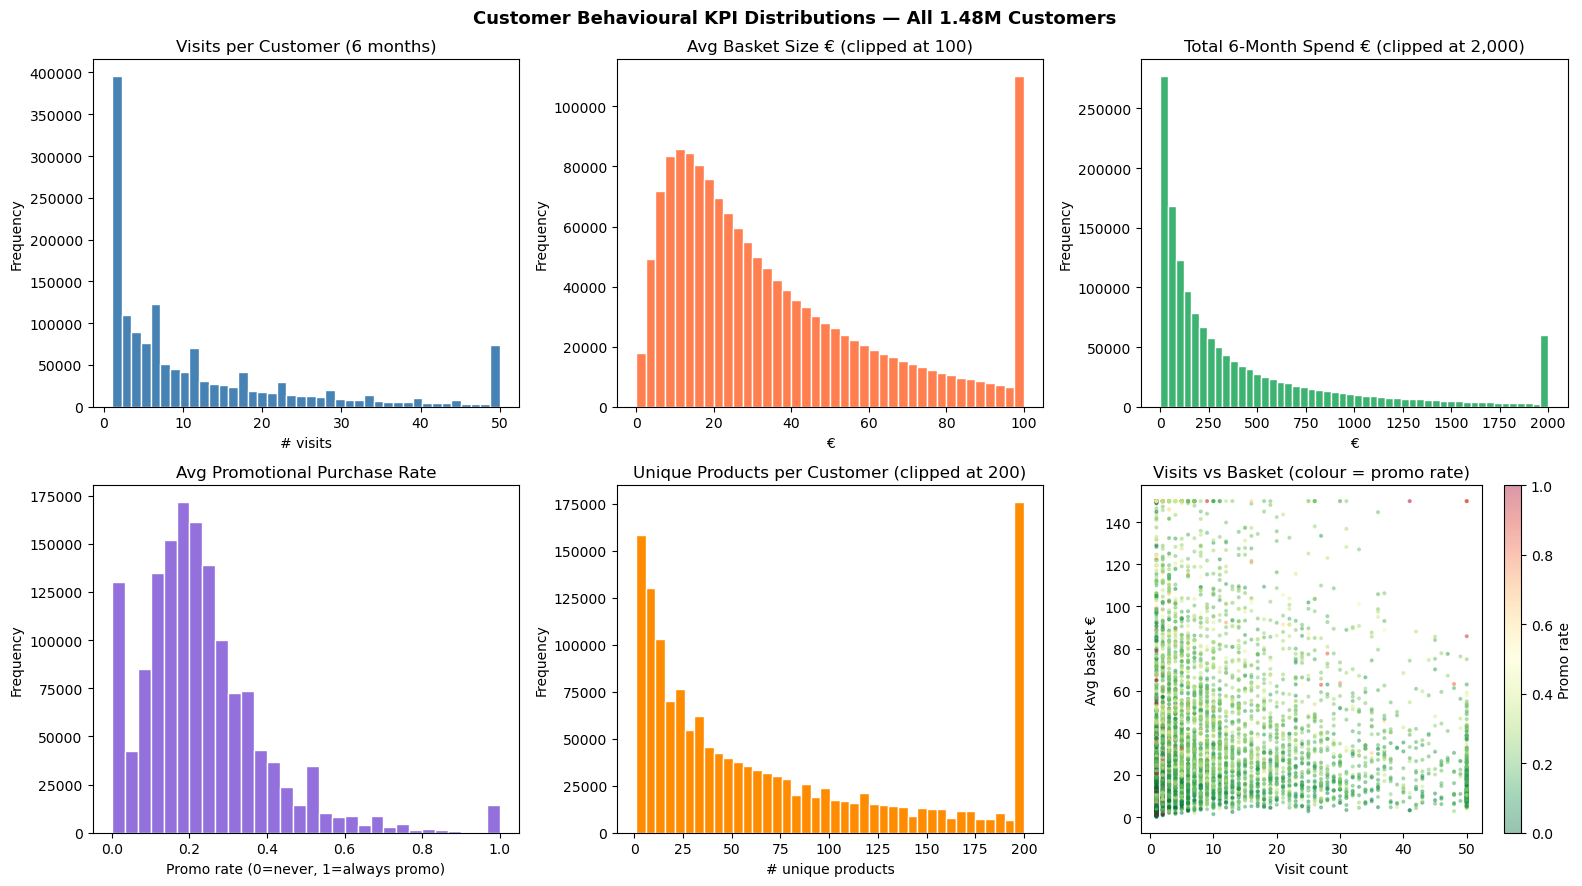

In [19]:
# ── 4.1 Per-customer KPI distributions (all 1.48M customers) ──────────────────
# KPIs are always computed from the prod dataset and cached in data/processed/.
from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"
_cache_path = PROD_PROCESSED / "customer_kpis.parquet"

if _cache_path.exists():
    cust_stats = pd.read_parquet(_cache_path)
    print(f"Loaded customer KPIs from cache ({len(cust_stats):,} rows)")
else:
    clean_lf = pl.scan_parquet(PROD_PROCESSED / "df_combined.parquet")

    basket_lf = (
        clean_lf
        .group_by(["cliente", "ticket"])
        .agg([
            pl.len().alias("n_items"),
            pl.col("importe").sum().alias("total_spend"),
            (pl.col("idpromoc") == "Promo").sum().cast(pl.Float64).alias("promo_items"),
        ])
        .with_columns((pl.col("promo_items") / pl.col("n_items")).alias("promo_rate"))
    )

    cust_lf = basket_lf.group_by("cliente").agg([
        pl.len().alias("visit_count"),
        pl.col("total_spend").mean().alias("avg_basket_size"),
        pl.col("total_spend").sum().alias("total_spend_6m"),
        pl.col("promo_rate").mean().alias("avg_promo_rate"),
    ])

    diversity_lf = clean_lf.group_by("cliente").agg(
        # approx_n_unique uses HyperLogLog (~1% error) — O(1) memory vs O(cardinality) for exact n_unique
        pl.col("idarticu").approx_n_unique().alias("unique_products")
    )

    # Two sequential streaming collects — each processes 190M rows in micro-batches,
    # keeping peak RAM proportional to batch size rather than full dataset size.
    cust_df      = cust_lf.collect(engine="streaming").to_pandas()
    diversity_df = diversity_lf.collect(engine="streaming").to_pandas()
    cust_stats   = cust_df.merge(diversity_df, on="cliente")

    cust_stats.to_parquet(_cache_path, index=False)
    print(f"Computed and cached customer KPIs → {_cache_path}")

print(f"Customer KPI summary (n={len(cust_stats):,}):")
print(cust_stats[["visit_count","avg_basket_size","total_spend_6m","avg_promo_rate","unique_products"]]
      .describe().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cust_stats["visit_count"].clip(upper=50).plot.hist(
    bins=40, ax=axes[0,0], color="steelblue", edgecolor="white",
    title="Visits per Customer (6 months)")
axes[0,0].set_xlabel("# visits")
cust_stats["avg_basket_size"].clip(upper=100).plot.hist(
    bins=40, ax=axes[0,1], color="coral", edgecolor="white",
    title="Avg Basket Size € (clipped at 100)")
axes[0,1].set_xlabel("€")
cust_stats["total_spend_6m"].clip(upper=2000).plot.hist(
    bins=50, ax=axes[0,2], color="mediumseagreen", edgecolor="white",
    title="Total 6-Month Spend € (clipped at 2,000)")
axes[0,2].set_xlabel("€")
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1,0], color="mediumpurple", edgecolor="white",
    title="Avg Promotional Purchase Rate")
axes[1,0].set_xlabel("Promo rate (0=never, 1=always promo)")
cust_stats["unique_products"].clip(upper=200).plot.hist(
    bins=40, ax=axes[1,1], color="darkorange", edgecolor="white",
    title="Unique Products per Customer (clipped at 200)")
axes[1,1].set_xlabel("# unique products")
s = cust_stats.sample(min(5000, len(cust_stats)), random_state=42)
sc = axes[1,2].scatter(s["visit_count"].clip(upper=50),
                        s["avg_basket_size"].clip(upper=150),
                        c=s["avg_promo_rate"], cmap="RdYlGn_r",
                        s=4, alpha=0.4)
plt.colorbar(sc, ax=axes[1,2], label="Promo rate")
axes[1,2].set_xlabel("Visit count"); axes[1,2].set_ylabel("Avg basket €")
axes[1,2].set_title("Visits vs Basket (colour = promo rate)")
plt.suptitle("Customer Behavioural KPI Distributions — All 1.48M Customers",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_customer_kpis.png", dpi=120)
plt.show()

### 4.2 Promotional Sensitivity Analysis

The `idpromoc` field flags whether each line item was purchased on promotion. This separates **brand loyalists** (buy regardless of price) from **promo surfers** (wait for discounts) — two archetypes worth very different things to Carrefour.

Strong signal here confirms that weaving a promo-sensitivity score into Phase 2 customer vectors will produce more commercially meaningful tribes.

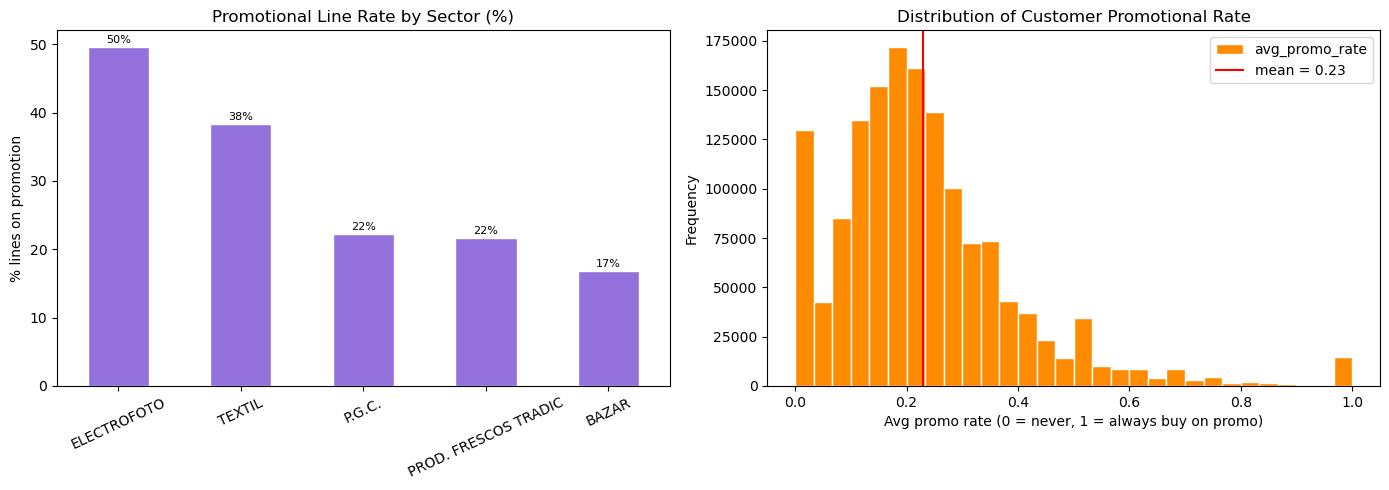

Overall promo rate in dataset    : 22.1%
Customers with 0% promo          : 8.1%
Customers with >50% promo        : 5.3%


In [20]:
# ── 5. Promotional sensitivity — sector and customer level ────────────────────
# key differentiating axis: promo surfers vs brand loyalists
promo_sector = (
    df_combined
    .drop_nulls("desc_sector")
    .group_by("desc_sector")
    .agg([
        pl.len().alias("total"),
        (pl.col("idpromoc") == "Promo").sum().alias("promo"),
    ])
    .with_columns((pl.col("promo").cast(pl.Float64) / pl.col("total") * 100).alias("promo_rate_pct"))
    .sort("promo_rate_pct", descending=True)
    .collect(engine="streaming")
    .to_pandas()
    .set_index("desc_sector")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
promo_sector["promo_rate_pct"].plot.bar(ax=axes[0], color="mediumpurple", edgecolor="white",
    title="Promotional Line Rate by Sector (%)")
axes[0].set_xlabel(""); axes[0].set_ylabel("% lines on promotion")
axes[0].tick_params(axis="x", rotation=25)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=8)
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1], color="darkorange", edgecolor="white",
    title="Distribution of Customer Promotional Rate")
axes[1].axvline(cust_stats["avg_promo_rate"].mean(), color="red", lw=1.5,
    label=f"mean = {cust_stats['avg_promo_rate'].mean():.2f}")
axes[1].legend()
axes[1].set_xlabel("Avg promo rate (0 = never, 1 = always buy on promo)")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_promo_analysis.png", dpi=120)
plt.show()

print(f"Overall promo rate in dataset    : {overall_promo_rate*100:.1f}%")
print(f"Customers with 0% promo          : {(cust_stats['avg_promo_rate'] == 0).mean()*100:.1f}%")
print(f"Customers with >50% promo        : {(cust_stats['avg_promo_rate'] > 0.5).mean()*100:.1f}%")

### 4.3 Customer Revenue Concentration (CLV Preview)

A Lorenz curve of customer spend shows how unequally revenue is distributed. If the top 10–20% of customers drive a disproportionate share of revenue, identifying and protecting those tribes becomes the primary commercial recommendation.

This is the most direct answer to "so what does Carrefour do with this?" — before we have even run the clustering.

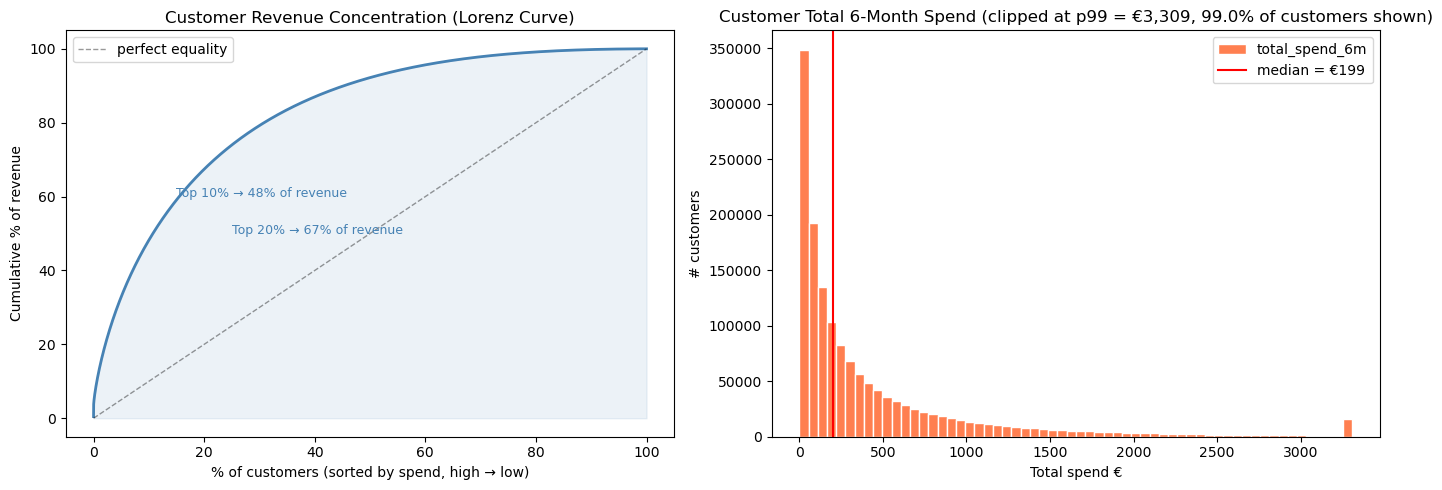

Top 10% of customers drive 48% of revenue
Top 20% of customers drive 67% of revenue
Median 6-month spend: €199
p99 spend (clip threshold): €3,309


In [21]:
# ── 6. Revenue concentration by customer (CLV preview) ───────────────────────
cust_stats_sorted = cust_stats.sort_values("total_spend_6m", ascending=False).reset_index(drop=True)
cust_stats_sorted["cumulative_rev_pct"] = (
    cust_stats_sorted["total_spend_6m"].cumsum() / cust_stats_sorted["total_spend_6m"].sum() * 100
)
cust_stats_sorted["customer_pct"] = (cust_stats_sorted.index + 1) / len(cust_stats_sorted) * 100

top10_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 10]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100
top20_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 20]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100

# clip threshold: 99th percentile — shows 99% of customers, cuts extreme outliers
_clip_p99 = cust_stats["total_spend_6m"].quantile(0.99)
_pct_shown = (cust_stats["total_spend_6m"] <= _clip_p99).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
             color="steelblue", lw=2)
axes[0].plot([0, 100], [0, 100], "k--", lw=1, alpha=0.4, label="perfect equality")
axes[0].fill_between(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
                     alpha=0.1, color="steelblue")
axes[0].set_xlabel("% of customers (sorted by spend, high → low)")
axes[0].set_ylabel("Cumulative % of revenue")
axes[0].set_title("Customer Revenue Concentration (Lorenz Curve)")
axes[0].text(15, 60, f"Top 10% → {top10_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].text(25, 50, f"Top 20% → {top20_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].legend()

cust_stats["total_spend_6m"].clip(upper=_clip_p99).plot.hist(
    bins=60, ax=axes[1], color="coral", edgecolor="white",
    title=f"Customer Total 6-Month Spend (clipped at p99 = €{_clip_p99:,.0f}, {_pct_shown:.1f}% of customers shown)")
axes[1].set_xlabel("Total spend €"); axes[1].set_ylabel("# customers")
axes[1].axvline(cust_stats["total_spend_6m"].median(), color="red", lw=1.5,
    label=f"median = €{cust_stats['total_spend_6m'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "eda_revenue_concentration.png", dpi=120)
plt.show()
print(f"Top 10% of customers drive {top10_share:.0f}% of revenue")
print(f"Top 20% of customers drive {top20_share:.0f}% of revenue")
print(f"Median 6-month spend: €{cust_stats['total_spend_6m'].median():.0f}")
print(f"p99 spend (clip threshold): €{_clip_p99:,.0f}")

### 4.4 Segmentation Viability — Go / No-Go

Formal go/no-go before committing to model training. CV > 0.5 per KPI = enough behavioral spread to expect separable clusters. If any KPI fails, investigate before proceeding.

In [22]:
# ── 8. Segmentation viability summary ────────────────────────────────────────
# coefficient of variation (CV = std/mean): CV > 0.5 is promising for clustering

print("=" * 65)
print("  SEGMENTATION VIABILITY ASSESSMENT")
print("=" * 65)
print()

kpi_labels = {
    "visit_count"    : "Visits per customer (6m)",
    "avg_basket_size": "Avg basket size €",
    "total_spend_6m" : "Total spend € (6m)",
    "avg_promo_rate" : "Promo sensitivity rate",
    "unique_products": "Product variety (# unique SKUs)",
}

for col, label in kpi_labels.items():
    vals   = cust_stats[col]
    cv     = vals.std() / vals.mean()
    signal = "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK")
    print(f"  {label:<40} CV={cv:.2f}  [{signal}]")

print()
print(f"  Unique customers in dataset     : {len(cust_stats):,}")
print(f"  Unique products in dataset      : {n_products:,}")
print(f"  Overall promo rate              : {overall_promo_rate*100:.1f}%")
print()
print("Conclusion:")
high_cv = sum(
    1 for col in kpi_labels
    if cust_stats[col].std() / cust_stats[col].mean() > 0.5
)
print(f"  {high_cv}/{len(kpi_labels)} KPIs show CV > 0.5 — {'sufficient' if high_cv >= 3 else 'marginal'} "
      "behavioural variance for clustering.")
print("  The data supports discovery of distinct purchase-behaviour tribes.")
print("=" * 65)

  SEGMENTATION VIABILITY ASSESSMENT

  Visits per customer (6m)                 CV=1.46  [STRONG]
  Avg basket size €                        CV=1.23  [STRONG]
  Total spend € (6m)                       CV=9.92  [STRONG]
  Promo sensitivity rate                   CV=0.72  [STRONG]
  Product variety (# unique SKUs)          CV=1.22  [STRONG]

  Unique customers in dataset     : 1,482,715
  Unique products in dataset      : 117,621
  Overall promo rate              : 22.1%

Conclusion:
  5/5 KPIs show CV > 0.5 — sufficient behavioural variance for clustering.
  The data supports discovery of distinct purchase-behaviour tribes.


### 4.5 EDA Summary

In [24]:
# ── 4.5 EDA Summary ───────────────────────────────────────────────────────────
import json
from IPython.display import display

with open(DATA_PROCESSED / "quality_report.json") as f:
    qr = json.load(f)

# ── Table 1: Dataset scale ─────────────────────────────────────────────────────
overview = pd.DataFrame([
    ("Unique customers",              f"{len(cust_stats):,}"),
    ("Clean transaction lines",       f"{qr['anomaly_audit']['rows_retained']:,}"),
    ("Unique products",               f"{n_products:,}"),
    ("Date range",                    "Jan 2022 – Jun 2022"),
    ("Stores",                        f"{qr['store_integrity']['n_stores']}"),
    ("Promotional purchase rate",     f"{overall_promo_rate*100:.1f}%"),
    ("Data quality gates passed",     "8 / 8"),
    ("Rows removed (returns/zeros)",  f"{qr['anomaly_audit']['rows_dropped_by_cleaning_rule']:,}  ({qr['anomaly_audit']['rows_dropped_pct']:.3f}%)"),
], columns=["Metric", "Value"]).set_index("Metric")

# ── Table 2: Behavioural spread per customer KPI ───────────────────────────────
# kpi_labels defined in Section 4.4 — reused here to avoid duplication
kpis = kpi_labels
rows = []
for col, label in kpis.items():
    vals = cust_stats[col]
    cv   = vals.std() / vals.mean()
    rows.append({
        "KPI":           label,
        "Median":        f"{vals.median():.1f}",
        "Mean":          f"{vals.mean():.1f}",
        "p25":           f"{vals.quantile(0.25):.1f}",
        "p75":           f"{vals.quantile(0.75):.1f}",
        "CV (std/mean)": f"{cv:.2f}",
        "Clustering signal": "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK"),
    })
behaviour = pd.DataFrame(rows).set_index("KPI")

# ── Table 3: Revenue concentration ────────────────────────────────────────────
_spend_desc = cust_stats["total_spend_6m"].sort_values(ascending=False).reset_index(drop=True)
_total      = _spend_desc.sum()
_n          = len(_spend_desc)
concentration = pd.DataFrame([
    ("Top 10% of customers",     f"{_spend_desc.iloc[:int(_n*0.10)].sum()/_total*100:.0f}% of total revenue"),
    ("Top 20% of customers",     f"{_spend_desc.iloc[:int(_n*0.20)].sum()/_total*100:.0f}% of total revenue"),
    ("Bottom 50% of customers",  f"{_spend_desc.iloc[int(_n*0.50):].sum()/_total*100:.0f}% of total revenue"),
    ("Median 6m spend",          f"€{_spend_desc.median():.0f}"),
    ("Mean 6m spend",            f"€{_spend_desc.mean():.0f}"),
    ("p99 6m spend",             f"€{_spend_desc.quantile(0.99):,.0f}"),
    ("Max 6m spend",             f"€{_spend_desc.max():,.0f}"),
], columns=["Metric", "Value"]).set_index("Metric")

# ── Display ────────────────────────────────────────────────────────────────────
print("=" * 55)
print("  TABLE 1 — DATASET OVERVIEW")
print("=" * 55)
display(overview)

print()
print("=" * 55)
print("  TABLE 2 — CUSTOMER BEHAVIOURAL SPREAD (per customer)")
print("=" * 55)
display(behaviour)

print()
print("=" * 55)
print("  TABLE 3 — REVENUE CONCENTRATION")
print("=" * 55)
display(concentration)

print()
print("=" * 55)
print("  KEY TAKEAWAYS FOR SEGMENTATION")
print("=" * 55)
high_cv = sum(1 for col in kpis if cust_stats[col].std() / cust_stats[col].mean() > 0.5)
print(f"  • {high_cv}/5 KPIs have CV > 0.5 — customers are behaviourally diverse")
print(f"  • Promo sensitivity ({overall_promo_rate*100:.1f}% avg) varies widely — a key tribe differentiator")
print(f"  • Revenue is highly concentrated — a small minority of customers drives most spend")
print(f"  • 8/8 data quality checks passed — dataset is clean and ready for modelling")

  TABLE 1 — DATASET OVERVIEW


,Value
Metric,
Unique customers,"1,482,715"
Clean transaction lines,"190,362,519"
Unique products,"117,621"
Date range,Jan 2022 – Jun 2022
Stores,4
Promotional purchase rate,22.1%
Data quality gates passed,8 / 8
Rows removed (returns/zeros),"655,196 (0.343%)"



  TABLE 2 — CUSTOMER BEHAVIOURAL SPREAD (per customer)


,Median,Mean,p25,p75,CV (std/mean),Clustering signal
KPI,,,,,,
Visits per customer (6m),7.0,13.5,2.0,17.0,1.46,STRONG
Avg basket size €,27.5,40.3,14.4,51.0,1.23,STRONG
Total spend € (6m),198.7,470.0,60.3,549.6,9.92,STRONG
Promo sensitivity rate,0.2,0.2,0.1,0.3,0.72,STRONG
Product variety (# unique SKUs),45.0,82.9,14.0,112.0,1.22,STRONG



  TABLE 3 — REVENUE CONCENTRATION


,Value
Metric,
Top 10% of customers,48% of total revenue
Top 20% of customers,67% of total revenue
Bottom 50% of customers,8% of total revenue
Median 6m spend,€199
Mean 6m spend,€470
p99 6m spend,"€3,309"
Max 6m spend,"€3,136,126"



  KEY TAKEAWAYS FOR SEGMENTATION
  • 5/5 KPIs have CV > 0.5 — customers are behaviourally diverse
  • Promo sensitivity (22.1% avg) varies widely — a key tribe differentiator
  • Revenue is highly concentrated — a small minority of customers drives most spend
  • 8/8 data quality checks passed — dataset is clean and ready for modelling


## Section 5 — Generate Dev Subset

Builds a stratified 44k-customer dev subset from the full production dataset.
Run this once after Sections 3 and 4 complete — both `df_combined.parquet` and `customer_kpis.parquet` must exist first.

**Stratification**: 18 strata = 3 visit-count tertiles × 3 spend tertiles × 2 store-affinity bins.
Proportional sampling within each stratum ensures the dev subset preserves the full population's behavioural distributions, confirmed by KS tests on all five KPIs.

**Output:** `data/dev/df_combined.parquet` + `data/dev/subset_metadata.json`

The cell is a no-op in dev mode (subset already built) and skips silently if the output already exists.

In [ ]:
# ── Section 5 — Generate dev subset (prod mode only) ─────────────────────────
# Reads data/processed/ outputs from Sections 3 & 4 and writes a stratified
# 44k-customer sample to data/dev/df_combined.parquet.
# Safe to re-run: skips if output already exists (pass force=True to regenerate).

from src.config import MODE
from scripts.generate_dev_subset import generate

if MODE == "prod":
    generate()
else:
    print(
        f"Skipping dev subset generation (MODE='{MODE}').\n"
        "To build or regenerate the dev subset, run this notebook in prod mode:\n"
        "  $env:CARREFOUR_MODE = 'prod'\n"
        "  jupyter notebook notebooks/02_pre-analysis.ipynb"
    )
    

Loading customer KPIs ...
  1,086,759 eligible customers  (dropped 395,956 with < 3 visits)
Computing per-customer store counts (streaming) ...
  1,051,137 single-store  /  431,578 multi-store customers
Assigning strata ...
  18 non-empty strata (of 18 possible):
    v_hi__s_hi__st1                             127,191
    v_hi__s_hi__st2p                            114,617
    v_hi__s_lo__st1                               8,486
    v_hi__s_lo__st2p                              8,070
    v_hi__s_md__st1                              44,394
    v_hi__s_md__st2p                             49,863
    v_lo__s_hi__st1                              17,809
    v_lo__s_hi__st2p                              3,588
    v_lo__s_lo__st1                             184,274
    v_lo__s_lo__st2p                             75,799
    v_lo__s_md__st1                              89,257
    v_lo__s_md__st2p                             27,088
    v_md__s_hi__st1                              67,003
    v_md